In [1]:
import pandas as pd

# Load the dataset (Assuming the file is in the same directory)
# If it's in a subfolder, use 'data/application_train.csv'
try:
    df = pd.read_csv('data/raw/home-credit-default-risk/application_train.csv')
    
    print("Dataset Loaded Successfully!")
    print(f"Total Rows: {df.shape[0]}")
    print(f"Total Columns: {df.shape[1]}")
    print("-" * 30)
    print("Here are the Headers (Column Names):")
    print(df.columns.tolist())

except FileNotFoundError:
    print("Error: 'application_train.csv' not found. Please check the file path.")

Dataset Loaded Successfully!
Total Rows: 307511
Total Columns: 122
------------------------------
Here are the Headers (Column Names):
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SO

In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. Check Class Imbalance
# ---------------------------------------------------------
target_counts = df['TARGET'].value_counts()
print("--- Class Distribution ---")
print(target_counts)
print(f"Default Rate: {(target_counts[1] / len(df)) * 100:.2f}%")
print("-" * 30)

# 2. Prepare Data for MVP Model (Numerical Only)
# ---------------------------------------------------------
# We select only numeric columns to avoid complex encoding for now.
# These map directly to your "What-If" Simulator sliders.
features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3' 
]

# Create X (Features) and y (Target)
X = df[features].copy()
y = df['TARGET']

# Quick Fix: XGBoost handles NaNs, but let's confirm data types are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# 3. Train/Test Split (80% Train, 20% Test)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train Baseline XGBoost
# ---------------------------------------------------------
print("Training Baseline XGBoost Model...")
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 5. Evaluate
# ---------------------------------------------------------
# We use probabilities (predict_proba) for AUC-ROC, not class labels (predict)
y_pred_prob = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"\nBaseline AUC-ROC Score: {auc_score:.4f}")
print("If this is above 0.70, your 'MVP' is already viable!")

--- Class Distribution ---
TARGET
0    282686
1     24825
Name: count, dtype: int64
Default Rate: 8.07%
------------------------------
Training Baseline XGBoost Model...


d:\FYP\Augmented-Decision-Support-Model\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:57:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Baseline AUC-ROC Score: 0.7485
If this is above 0.70, your 'MVP' is already viable!


d:\FYP\Augmented-Decision-Support-Model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating Global Feature Importance...


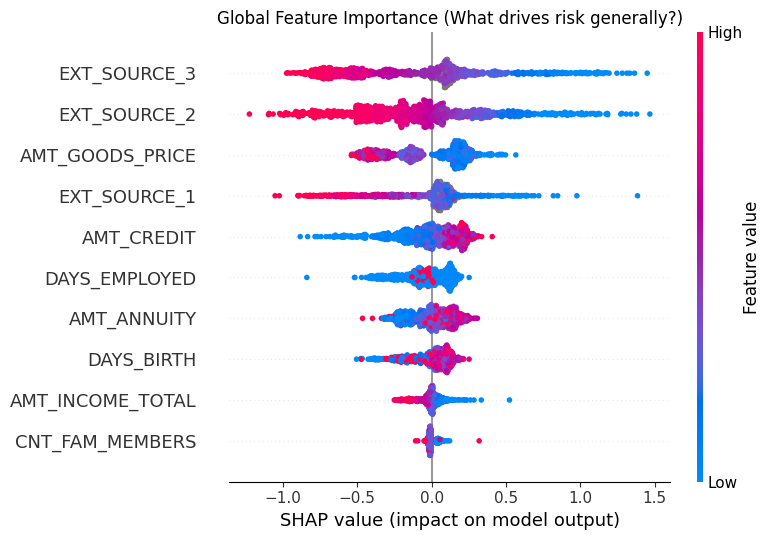


Analyzing Applicant #110
Model Predicted Risk: 0.5436 (Very High)


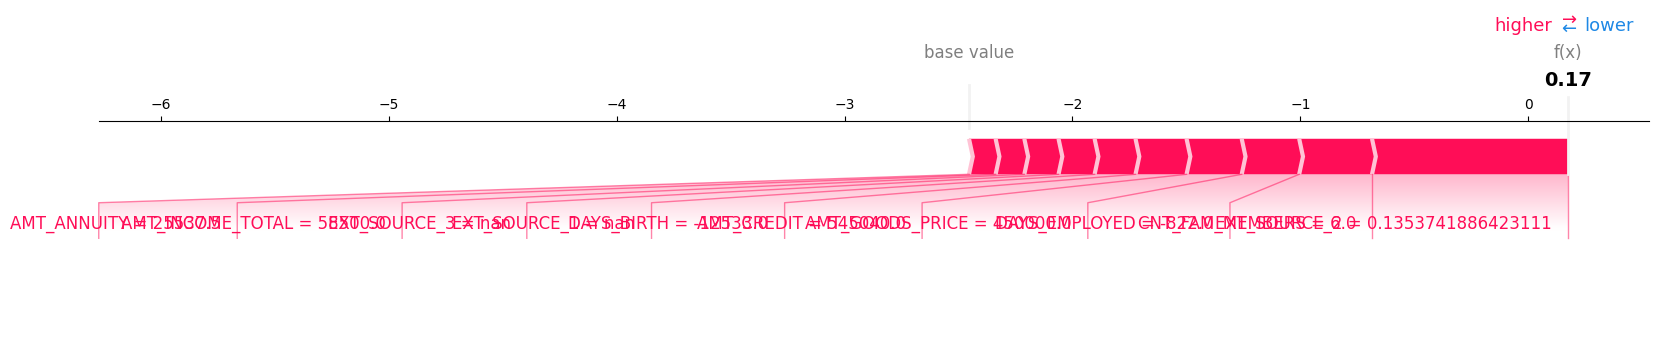

In [3]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
# ---------------------------------------------------------
# We use the model you just trained
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP Values (Use a subset to save time!)
# ---------------------------------------------------------
# SHAP is computationally expensive. We'll use just 1000 rows from X_test.
# This is enough for a prototype and prevents your laptop from freezing.
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

# 3. GLOBAL Explanation (Summary Plot)
# ---------------------------------------------------------
print("Generating Global Feature Importance...")
plt.figure()
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("Global Feature Importance (What drives risk generally?)")
plt.tight_layout()
plt.show()

# 4. LOCAL Explanation (Loan Officer View)
# ---------------------------------------------------------
# Let's pick a high-risk applicant from our sample to analyze.
# We look for an index where the model predicted a high probability of default.
y_pred_prob_sample = model.predict_proba(X_test_sample)[:, 1]
high_risk_idx = y_pred_prob_sample.argmax()  # Find the riskiest person

print(f"\nAnalyzing Applicant #{high_risk_idx}")
print(f"Model Predicted Risk: {y_pred_prob_sample[high_risk_idx]:.4f} (Very High)")

# Force Plot (The classic 'Push/Pull' chart)
# Note: In a notebook, this is interactive. For a React app, we will send the raw values.
shap.initjs()
shap_plot = shap.force_plot(
    explainer.expected_value, 
    shap_values[high_risk_idx], 
    X_test_sample.iloc[high_risk_idx],
    matplotlib=True
)

In [4]:
# Save model and column names
model.save_model("model_mvp.json")

# We also need to save the list of features so the API knows the order
pd.Series(features).to_json("model_features.json")

print("Model and features saved successfully!")

Model and features saved successfully!
